# Ray-tracing BER at Various TX/RX Antenna Bearing Angles
This notebook runs an end-to-end simulation of communication through ray-tracing channel models and measures the bit error rate (BER) at different bearing angles for both the transmit and receive antennas.

In [1]:
import numpy as np
import scipy.io
import time
import matplotlib.pyplot as plt

from neoradium import DeepMimoData, TrjChannel, Trajectory, Carrier, PDSCH, AntennaPanel, Grid, random


In [2]:
# Replace this with the folder on your computer where you store DeepMIMO scenarios
dataFolder = "/data/RayTracing/DeepMIMO/Scenarios/V4/"
DeepMimoData.setScenariosPath(dataFolder)

# Create a DeepMimoData object
deepMimoData = DeepMimoData("asu_campus_3p5")
deepMimoData.print()


DeepMimoData Properties:
  Scenario:                   asu_campus_3p5
  Version:                    4.0.0a3
  UE Grid:                    rx_grid
  Grid Size:                  411 x 321
  Base Station:               BS (at [166. 104.  22.])
  Total Grid Points:          131,931
  UE Spacing:                 [1. 1.]
  UE bounds (xyMin, xyMax)    [-225.55 -160.17], [184.45 159.83]
  UE Height:                  1.50
  Carrier Frequency:          3.5 GHz
  Num. paths (Min, Avg, Max): 0, 6.21, 10
  Num. total blockage:        46,774
  LOS percentage:             19.71%



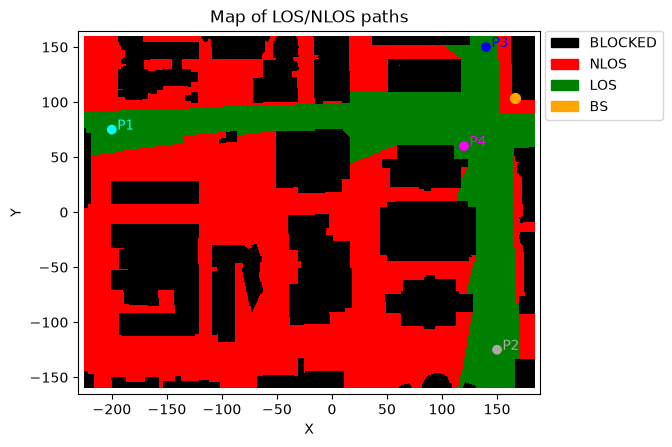

In [3]:
# We create channels between the base station and these four points
points = [[-200,75], [150,-125], [140,150], [120,60]]
colors = ["cyan", "darkgray", "blue", "magenta"] 
# Create the carrier:
carrier = Carrier(startRb=0, numRbs=25, spacing=30) # Carrier with 25 Resource Blocks, 15KHz subcarrier spacing
bwp = carrier.curBwp                                # The only bandwidth part in the carrier

# Let's draw the map and show the above four points on the map with small blue circles
ax = deepMimoData.drawMap("LOS-NLOS")
x = [point[0] for point in points]
y = [point[1] for point in points]
ax.scatter(x=x, y=y, c=colors)
for i, point in enumerate(points):
    ax.annotate(f"P{i+1}", (x[i], y[i]), textcoords="offset points", xytext=(10,0), ha='center', color=colors[i])

# Create 1-point trajectories. Each trajectory contains only one point. Since we just want to study the bearing
# angles, we don't need a real trajectory.
trajectories = []
for point in points:
    gridXy = deepMimoData.xyToGridXy(point)
    gridIdx = deepMimoData.gridXyToIndex(gridXy)
    trajPoint = deepMimoData[gridIdx]
    trajPoint.speed = np.array([14.0,0.0,0.0])
    trajPoint.sampleNo = 1
    trajectories += [Trajectory([deepMimoData[gridIdx]], deepMimoData.carrierFreq)]


In [4]:
def getBitrateInfo(numSlots, snrDbs, freqDomain, pdsc, trajectory, txAlphas, rxAlphas, seed=123, quiet=False):
    results = {}                # Dictionary to save the results
    for snrDb in snrDbs:
        random.setSeed(seed)    # Making the results reproducible.
        t0 = time.time()
        results[snrDb]={}
        if not quiet:
            print(f"\nSimulating end-to-end at SNR={snrDb} db in {'frequency' if freqDomain else 'time'} domain for different TX/RX antenna orientations.")
            print("TxAlpha   RxAlpha   Total Bits   Bit Errors   BER(%)   Slot     time(Sec.)")
            print("-------   -------   ----------   ----------   ------   -----    ----------")
    
        for txAlpha in txAlphas:
            results[snrDb][txAlpha] = {}
            for rxAlpha in rxAlphas:
                channel = TrjChannel(bwp, trajectory, 
                                     txAntenna = AntennaPanel([2,4]),       # 8 TX antenna
                                     txOrientation = [txAlpha,0,0],
                                     rxAntenna = AntennaPanel([1,2]),       # 2 RX antenna
                                     rxOrientation = [rxAlpha,0,0],
                                     seed = seed)
               
                bitErrors = 0
                totalBits = 0
        
                for slotNo in range(numSlots):
                    pdsch.initGrid()                             # Create and initialize PDSCH's internal grid
                    numBits = pdsch.getBitCapacity()[0]          # Actual number of bits available in the resource grid
                    txBits = random.bits(numBits)                # Create random binary data
        
                    # Now populate the resource grid with coded data. This includes QAM modulation and resource mapping.
                    pdsch.setPdschData(txBits)
        
                    # Getting the Precoding Matrix, and precoding the resource grid
                    channelMatrix = channel.getChannelMatrix()              # Get the channel matrix
                    precoder = pdsch.getPrecodingMatrix(channelMatrix)      # Get the precoder matrix from PDSCH object
                    
                    txGrid = bwp.createGrid(channel.nrNt[1])                # Create the transmitted resource grid
                    pdsch.precodeTo(txGrid, precoder)                       # Perform precoding
        
                    if freqDomain:
                        rxGrid = txGrid.applyChannel(channelMatrix)         # Apply the channel in frequency domain
                        rxGrid = rxGrid.addNoise(snrDb=snrDb)               # Add noise
                    else:
                        txWaveform = txGrid.ofdmModulate()                  # OFDM Modulation
                        maxDelay = channel.getMaxDelay()                    # Get the max. channel delay
                        txWaveform = txWaveform.pad(maxDelay)               # Pad with zeros
                        rxWaveform = channel.applyToSignal(txWaveform)      # Apply channel in time domain
                        noisyRxWaveform = rxWaveform.addNoise(snrDb=snrDb, bwp=bwp)     # Add noise
                        offset = channel.getTimingOffset()                  # Get timing info for synchronization
                        syncedWaveform = noisyRxWaveform.sync(offset)       # Synchronization
                        rxGrid = syncedWaveform.ofdmDemodulate(bwp)         # OFDM demodulation
        
                    estChannelMatrix = channelMatrix @ precoder[None,...]   # Perfect Channel Estimation
        
                    eqGrid, llrScales = pdsch.equalize(rxGrid, estChannelMatrix)# Equalization
                    rxBits = pdsch.getHardBits(eqGrid)[0]                       # Demodulation
                    bitErrors += np.abs(rxBits-txBits).sum()                    # Calculating number of bit errors
                    totalBits += numBits
                    if not quiet:
                        print("\r %4d     %4d      %8d     %8d    %6.2f  %6d      %6.2f"%(txAlpha, rxAlpha, totalBits, bitErrors, 
                                                                                          bitErrors*100/totalBits, slotNo+1,
                                                                                          time.time()-t0), end='')
        
                dt = time.time()-t0                         # Total time for this SNR
                results[snrDb][txAlpha][rxAlpha] = {"totalBits":totalBits, 
                                                    "bitErrors":bitErrors, 
                                                    "BER":      bitErrors*100/totalBits,
                                                    "Time":     dt}
                if not quiet:
                    print("\r %4d     %4d      %8d     %8d    %6.2f  %6d      %6.2f"%(txAlpha, rxAlpha, totalBits, bitErrors, 
                                                                                      bitErrors*100/totalBits, slotNo+1, dt))

    return results



## Different TX Bearing Angles

Running at UE position P1: (-199.55, 74.83) ...
Running at UE position P2: (150.45, -125.17) ...
Running at UE position P3: (140.45, 149.83) ...
Running at UE position P4: (120.45, 59.83) ...


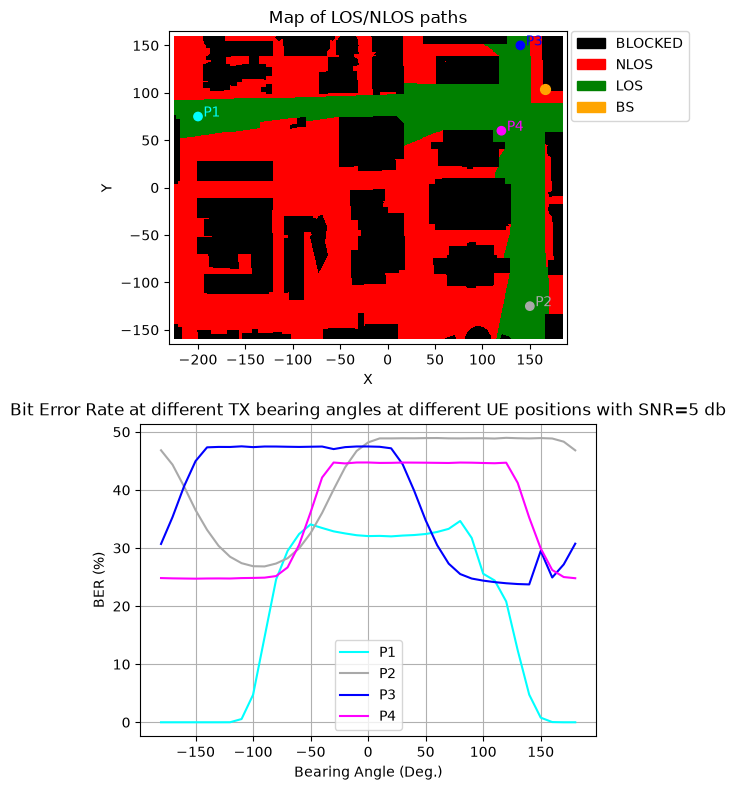

In [5]:
# Create a PDSCH object
pdsch = PDSCH(bwp, numLayers=2, nID=carrier.cellId, modulation="16QAM")
pdsch.setDMRS(prgSize=0, configType=2, additionalPos=2)     # Specify the DMRS configuration

txAlphas=range(-180,181,10)
rxAlphas=[0]

# Draw the map and the four points again for the reference
fig, ax = plt.subplots(2,1, figsize=(6,8))
ax0 = deepMimoData.drawMap("LOS-NLOS", ax=ax[0])
x = [point[0] for point in points]
y = [point[1] for point in points]
ax0.scatter(x=x, y=y, c=colors)
for i, point in enumerate(points):
    ax0.annotate(f"P{i+1}", (x[i], y[i]), textcoords="offset points", xytext=(10,0), ha='center', color=colors[i])

snrDb=5
for i,trj in  enumerate(trajectories):
    print(f"Running at UE position P{i+1}: ({trj[0].xyz[0]:.2f}, {trj[0].xyz[1]:.2f}) ...")
    allResults = getBitrateInfo(numSlots=50, snrDbs=[snrDb], freqDomain=True,
                                pdsc=pdsch, trajectory=trj, txAlphas=txAlphas, rxAlphas=rxAlphas, 
                                quiet=True)

    if len(rxAlphas)==1:   bers = [allResults[snrDb][txAlpha][rxAlphas[0]]["BER"] for txAlpha in txAlphas]
    else:                  bers = [allResults[snrDb][txAlphas[0]][rxAlpha]["BER"] for rxAlpha in rxAlphas]
    ax[1].plot(range(-180,181,10), bers, label=f"P{i+1}", color=colors[i])
    
ax[1].set_title(f"Bit Error Rate at different {'TX' if len(rxAlphas)==1 else 'RX'} bearing angles at different UE positions with SNR={snrDb} db");
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel("Bearing Angle (Deg.)")
ax[1].set_ylabel("BER (%)")
plt.tight_layout()
plt.show()

## Different RX Bearing Angles

Running at UE position P1: (-199.55, 74.83) ...
Running at UE position P2: (150.45, -125.17) ...
Running at UE position P3: (140.45, 149.83) ...
Running at UE position P4: (120.45, 59.83) ...


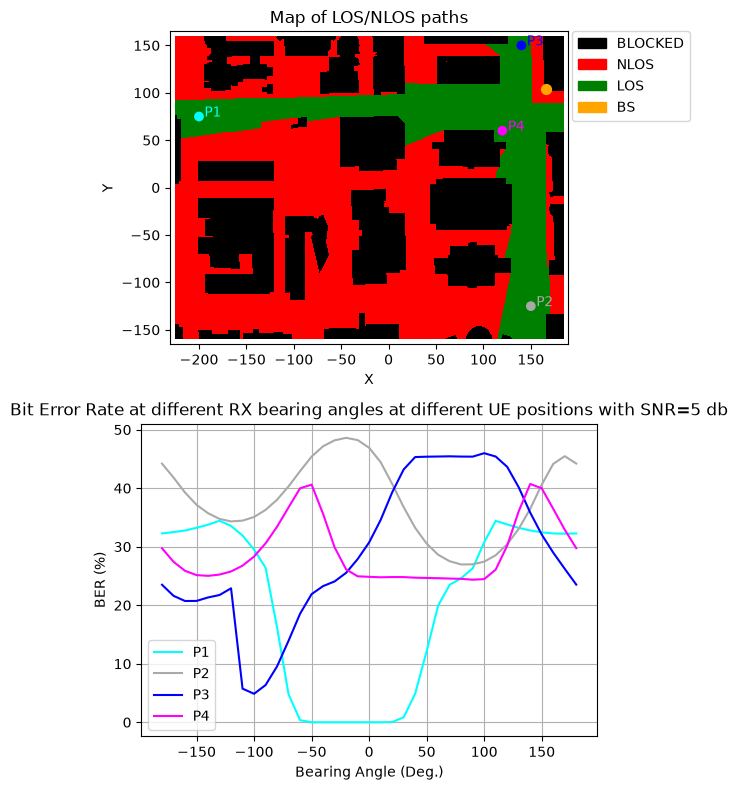

In [6]:
txAlphas=[180]
rxAlphas=range(-180,181,10)

# Draw the map and the four points again for the reference
fig, ax = plt.subplots(2,1, figsize=(6,8))

ax0 = deepMimoData.drawMap("LOS-NLOS", ax=ax[0])          # Draw the Map with the trajectory
x = [point[0] for point in points]
y = [point[1] for point in points]
ax0.scatter(x=x, y=y, c=colors)
for i, point in enumerate(points):
    ax0.annotate(f"P{i+1}", (x[i], y[i]), textcoords="offset points", xytext=(10,0), ha='center', color=colors[i])

snrDb=5
for i,trj in  enumerate(trajectories):
    print(f"Running at UE position P{i+1}: ({trj[0].xyz[0]:.2f}, {trj[0].xyz[1]:.2f}) ...")
    allResults = getBitrateInfo(numSlots=50, snrDbs=[snrDb], freqDomain=True,
                                pdsc=pdsch, trajectory=trj, txAlphas=txAlphas, rxAlphas=rxAlphas, 
                                quiet=True)

    if len(rxAlphas)==1:   bers = [allResults[snrDb][txAlpha][rxAlphas[0]]["BER"] for txAlpha in txAlphas]
    else:                  bers = [allResults[snrDb][txAlphas[0]][rxAlpha]["BER"] for rxAlpha in rxAlphas]
    ax[1].plot(range(-180,181,10), bers, label=f"P{i+1}", color=colors[i])
    
ax[1].set_title(f"Bit Error Rate at different {'TX' if len(rxAlphas)==0 else 'RX'} bearing angles at different UE positions with SNR={snrDb} db");
ax[1].grid()
ax[1].legend()
ax[1].set_xlabel("Bearing Angle (Deg.)")
ax[1].set_ylabel("BER (%)")
plt.tight_layout()
plt.show()